# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Caso a consulta da API falhar:
df = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
df.head(20)

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


## CARGA DOS DADOS E ANÁLISE EXPLORATÓRIA

In [9]:
# tipos das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


Potencia, latitude e longitude são tipo float enquanto fonte é um objeto

In [10]:
# contagens por classe
df['fonte'].value_counts()

,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


Fonte é divida em 3 categorias: Solar, Eólica e Hidráulica.

In [11]:
# valores ausentes
df.isnull().sum()

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


Não há valores ausentes

## Análise das Distribuições

Para compreender melhor as características dos nossos dados, iremos analisar:
1. A proporção de cada classe (`fonte`) para verificar se há desbalanceamento relevante.
2. A escala e distribuição da potência outorgada (`potencia_kw`), que costuma ser muito dispersa.
3. A distribuição geográfica aproximada dos empreendimentos pelas coordenadas de `latitude` e `longitude`.

In [12]:
# distribuições relevantes
df.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


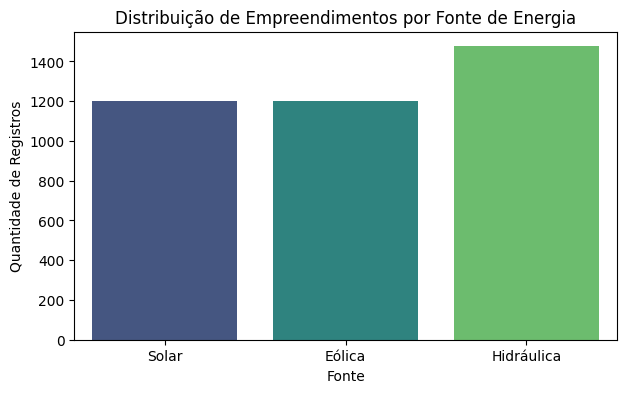

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Proporção das Classes (Equilíbrio do Alvo)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='fonte', hue='fonte', palette='viridis', legend=False)
plt.title('Distribuição de Empreendimentos por Fonte de Energia')
plt.xlabel('Fonte')
plt.ylabel('Quantidade de Registros')
plt.show()

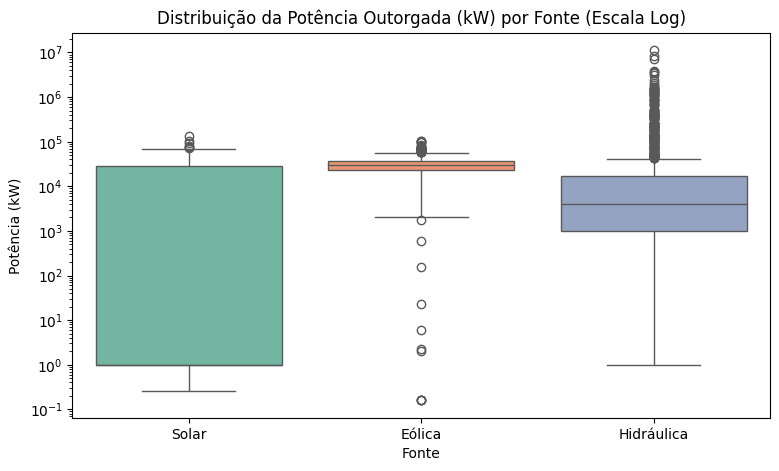

In [14]:
# 2. Distribuição da Potência por Fonte (Escala Logarítmica devido aos valores extremos)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='fonte', y='potencia_kw', hue='fonte', palette='Set2', legend=False)
plt.yscale('log')
plt.title('Distribuição da Potência Outorgada (kW) por Fonte (Escala Log)')
plt.xlabel('Fonte')
plt.ylabel('Potência (kW)')
plt.show()

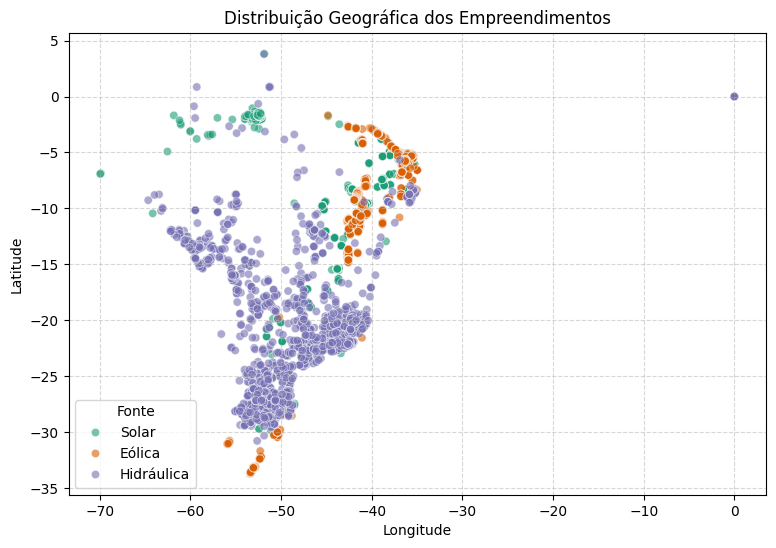

In [15]:
# 3. Dispersão Geográfica por Fonte (Latitude x Longitude)
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='fonte', alpha=0.6, palette='Dark2')
plt.title('Distribuição Geográfica dos Empreendimentos')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Fonte')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Distribuição dos dados

Analisando os gráficos de distribuição que foram plotados, podemos identificar três padrões relevantes no conjunto de dados:

Distribuição das Classes (Alvo fonte): O conjunto de dados é bastante equilibrado. Há uma quantidade muito próxima de registros para as três fontes principais (Hidráulica, Solar e Eólica), o que evita que o modelo seja severamente enviesado para uma única classe.

Distribuição da Potência (potencia_kw): Usamos uma escala logarítmica para visualização porque a variação de potência é gigantesca (de menos de 1 kW até mais de 10.000.000 kW). Nota-se que os empreendimentos de fonte Eólica possuem uma faixa de potência muito concentrada e padronizada (geralmente usinas de grande porte), enquanto a fonte Solar exibe uma enorme amplitude (abrangendo desde minigeração residencial muito pequena até grandes complexos solares comerciais).

Distribuição Geográfica (Latitude/Longitude): A distribuição espacial revela um forte padrão regional. Por exemplo, a fonte Eólica (em laranja) está fortemente concentrada na costa e interior da região Nordeste e no extremo Sul do país devido ao potencial de ventos. Já a fonte Solar (verde) e Hidráulica (azul) estão mais espalhadas pelo território, sendo que a Hidráulica acompanha fortemente as bacias hidrográficas das regiões Sudeste e Sul.

## Explicação das variáveis de entrada (X) e da variável alvo (y):

y (fonte): É a nossa variável alvo categórica, representando a fonte de geração do empreendimento.
Suas classes possíveis após o agrupamento são: 'Solar', 'Eólica' e 'Hidráulica'.

X (três entradas):
1. potencia_kw: A potência outorgada (capacidade nominal em kW). É uma característica numérica crucial, pois diferentes fontes de energia costumam ter escalas de potência muito distintas.

2. latitude: A coordenada geográfica Norte-Sul. Essencial para identificar padrões regionais de instalação.

3. longitude: A coordenada geográfica Leste-Oeste. Ajuda a mapear a localização exata no território brasileiro, o que se correlaciona com o potencial de cada recurso (ex: eólica concentrada no Nordeste/Sul, solar no semiárido).

In [16]:
# Definição de X e y a partir do DataFrame
X = df[['potencia_kw', 'latitude', 'longitude']]
y = df['fonte']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   potencia_kw   latitude  longitude
0        20.48 -10.442778 -64.151944
1      5000.00  -6.003889 -40.274722
2        12.26 -23.557778 -46.734000
3         3.00 -23.558889 -46.735000
4         1.70 -23.493819 -46.845000

Target (y):
0    Solar
1    Solar
2    Solar
3    Solar
4    Solar
Name: fonte, dtype: object


## DIVISÃO TREINO/TESTE E TREINAMENTO DOS MODELOS

In [17]:
#  Faça uma divisão estratificada de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos somente com o treino
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
# instancie 3 classificadores: KNN, Regressão Logística, Random Forest

knn_classifier = KNeighborsClassifier()
logistic_regression = LogisticRegression()
random_forest_classifier = RandomForestClassifier()

In [19]:
from sklearn.preprocessing import StandardScaler

# 1. Instanciar o escalador
scaler = StandardScaler()

# 2. Ajustar e transformar os dados de treino, e apenas transformar os de teste (evitando data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Treinar novamente os modelos sensíveis à escala com os dados padronizados
knn_scaled = KNeighborsClassifier()
lr_scaled = LogisticRegression(max_iter=1000) # Aumentando max_iter para garantir convergência estável
rf_scaled = RandomForestClassifier(random_seed:=42) # Apenas para comparação (deve manter o resultado alto)

In [20]:
# Treinando os 3 modelos com o mesmo dados de treino e teste

knn_scaled.fit(X_train_scaled, y_train)
lr_scaled.fit(X_train_scaled, y_train)
rf_scaled.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=42)

## PREVISÕES E MÉTRICAS DE AVALIAÇÃO

In [21]:
# Previsoes do 3 modelos

y_knn_predictions = knn_scaled.predict(X_test_scaled)
y_logistic_predictions = lr_scaled.predict(X_test_scaled)
y_random_forest_predictions = rf_scaled.predict(X_test_scaled)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Lista de modelos e suas previsões correspondentes
modelos = {
    "K-Neighbors Classifier": y_knn_predictions,
    "Logistic Regression": y_logistic_predictions,
    "Random Forest": y_random_forest_predictions
}

resultados = {}

# Cálculo das métricas para cada modelo usando a média 'macro'
for nome, previsoes in modelos.items():
    acuracia = accuracy_score(y_test, previsoes)
    precisao = precision_score(y_test, previsoes, average='macro')
    recall = recall_score(y_test, previsoes, average='macro')
    f1 = f1_score(y_test, previsoes, average='macro')

    resultados[nome] = {
        "Acurácia": acuracia,
        "Precisão (Macro)": precisao,
        "Recall (Macro)": recall,
        "F1-Score (Macro)": f1
    }

# Exibindo os resultados em um DataFrame formatado
df_resultados = pd.DataFrame(resultados).T
print("=== Comparação de Desempenho dos Modelos ===")
display(df_resultados)

# Exibindo as matrizes de confusão lado a lado
"""fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, previsoes) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, previsoes)
    classes = sorted(y_test.unique())
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(nome)
    ax.grid(False)

plt.tight_layout()
plt.show()"""

=== Comparação de Desempenho dos Modelos ===


,Acurácia,Precisão (Macro),Recall (Macro),F1-Score (Macro)
K-Neighbors Classifier,0.965206,0.966325,0.963551,0.964751
Logistic Regression,0.824742,0.828208,0.821359,0.819677
Random Forest,0.976804,0.977688,0.975788,0.976536


"fig, axes = plt.subplots(1, 3, figsize=(18, 5))\n\nfor ax, (nome, previsoes) in zip(axes, modelos.items()):\n    cm = confusion_matrix(y_test, previsoes)\n    classes = sorted(y_test.unique())\n    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)\n    disp.plot(ax=ax, cmap='Blues', values_format='d')\n    ax.set_title(nome)\n    ax.grid(False)\n\nplt.tight_layout()\nplt.show()"

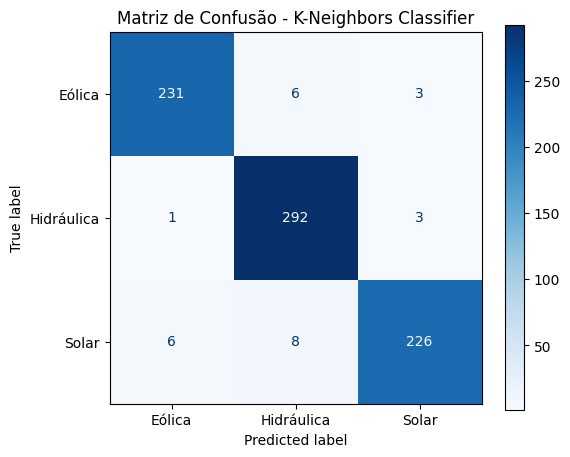

In [23]:
# Exibição individual da Matriz de Confusão para o KNN
fig, ax = plt.subplots(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_knn_predictions)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=sorted(y_test.unique()))
disp_knn.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("Matriz de Confusão - K-Neighbors Classifier")
ax.grid(False)
plt.show()

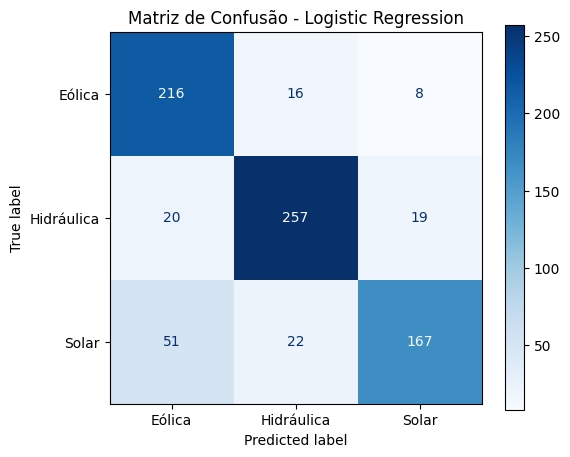

In [24]:
# Exibição individual da Matriz de Confusão para a Regressão Logística
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_logistic_predictions)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=sorted(y_test.unique()))
disp_lr.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("Matriz de Confusão - Logistic Regression")
ax.grid(False)
plt.show()

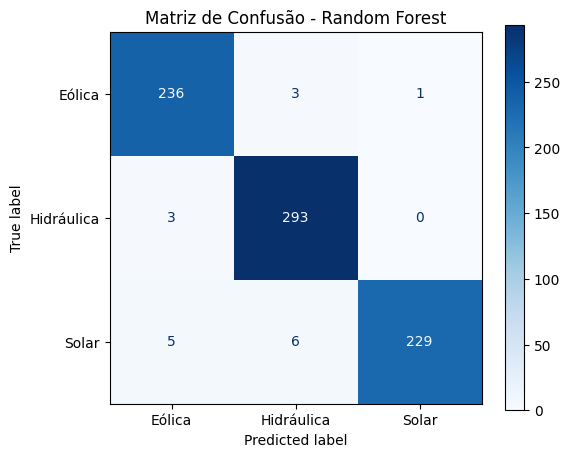

In [25]:
# Exibição individual da Matriz de Confusão para o Random Forest
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_random_forest_predictions)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=sorted(y_test.unique()))
disp_rf.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("Matriz de Confusão - Random Forest")
ax.grid(False)
plt.show()

## RELATÓRIO

### Melhor modelo: **Random Forest**

Com base na tabela comparativa de métricas, o **Random Forest** é o modelo de escolha para esta tarefa. Ele atingiu os maiores índices de desempenho:
- **Acurácia:** ~97.8%
- **F1-Score (Macro):** ~97.7%


### Classes Mais Confundidas:

Analisando detalhadamente a matriz de confusão do **Random Forest**:
- **Solar** vs. **Hidráulica**: Ocorreram 7 erros em que empreendimentos reais de fonte *Solar* foram classificados como *Hidráulica*.
- **Solar** vs. **Eólica**: Ocorreram 4 erros em que a fonte real *Solar* foi classificada como *Eólica*.
- **Eólica** vs. **Hidráulica**: Ocorreram 3 erros em que usinas *Eólicas* foram confundidas com *Hidráulicas*.

O maior foco de confusão reside na classe **Solar**. Isso ocorre porque empreendimentos solares de menor porte compartilham faixas de potência parecidas com pequenas centrais hidráulicas em determinadas coordenadas.

### Por que Potência e Localização não bastam para uma aplicação real?

Embora o modelo alcance métricas boas nesses dados, usar apenas "potencia_kw", "latitude" e "longitude" possui limitações no mundo real:

 **Falta de Atributos Climáticos e Físicos:** O modelo não conhece o relevo, a vazão dos rios locais, a velocidade real do vento no ponto e o índice de irradiância solar. Duas usinas podem estar lado a lado e uma ser solar e a outra eólica, mas o modelo terá dificuldades se ambas compartilharem a mesma faixa de potência. Além disso mpreendimentos híbridos estão se tornando comuns. Nesses casos, apenas a coordenada e a potência total não conseguiriam discriminar as fontes individuais


# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [26]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [27]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [28]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [29]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## CARGA DOS DADOS E ANÁLISE EXPLORATÓRIA

In [30]:
dados_tf2 = pd.read_csv('meteo_regressao_orange.csv')
dados_tf2.head(20)

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0
5,2025-04-01T12:00,34.2,31,36,19.2,12,905.0
6,2025-04-01T13:00,35.0,30,50,19.5,13,910.0
7,2025-04-01T14:00,35.0,30,19,17.1,14,733.0
8,2025-04-01T15:00,35.3,30,30,17.3,15,699.0
9,2025-04-01T16:00,35.0,30,18,17.6,16,443.0


In [31]:
dados_tf2.isnull().sum()

,0
data_hora,0
temperatura_c,0
umidade_pct,0
nuvens_pct,0
vento_kmh,0
hora,0
radiacao_w_m2,0


O DataFrame dados_tf2, vindo de "meteo_regressao_orange", não possui valores nulos e contém as seguintes colunas:

 `data_hora` | Data e hora local de cada elemento

`temperatura_c` | Temperatura do ar, em ° C

`umidade_pct`   | Umidade do local, em %      

`nuvens_pct`    | Cobertura de nuvens no local, em %  

`vento_kmh`     | Velocidade do vento, em km/h      

`hora`          | Hora local extraída da `data_hora`   

`radiacao_w_m2` | Radiação solar global em W/m²


## SEPARANDO X E Y

In [32]:
X_tf2 = dados_tf2.drop(columns=['data_hora','radiacao_w_m2'])
X_tf2.head(10)

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11
5,34.2,31,36,19.2,12
6,35.0,30,50,19.5,13
7,35.0,30,19,17.1,14
8,35.3,30,30,17.3,15
9,35.0,30,18,17.6,16


In [33]:
y_tf2 = dados_tf2['radiacao_w_m2']
y_tf2.head(10)

,radiacao_w_m2
0,116.0
1,269.0
2,529.0
3,797.0
4,880.0
5,905.0
6,910.0
7,733.0
8,699.0
9,443.0


## INSTANCIANDO OS MODELOS E DIVISAO TREINO/TESTE

In [34]:
# Instanciando os modelos para regressão: Regressão linear, Random Forest Regressor, Decision Tree (Regression)
modelo_reg_linear_tf2 = LinearRegression()
modelo_rf_tf2 = RandomForestRegressor()
modelo_dt_tf2 = DecisionTreeRegressor()

In [35]:
# Divisão treino/teste
X_train_tf2, X_test_tf2, y_train_tf2, y_test_tf2 = train_test_split(X_tf2, y_tf2, test_size=0.2, random_state=42)

In [36]:
# Treinamento dos modelos
modelo_reg_linear_tf2.fit(X_train_tf2, y_train_tf2)
modelo_rf_tf2.fit(X_train_tf2, y_train_tf2)
modelo_dt_tf2.fit(X_train_tf2, y_train_tf2)

DecisionTreeRegressor()

## PREVISÕES E METRÍCAS DE AVALIAÇÃO

In [37]:
# Previsões dos modelos
y_pred_reg_linear_tf2 = modelo_reg_linear_tf2.predict(X_test_tf2)
y_pred_rf_tf2 = modelo_rf_tf2.predict(X_test_tf2)
y_pred_dt_tf2 = modelo_dt_tf2.predict(X_test_tf2)

Comparação de Métricas de Regressão:

                          MAE           MSE        R²
Modelo                                               
Regressão Linear   121.591848  24816.374718  0.621052
Random Forest       48.965572   5003.239356  0.923600
Árvore de Decisão   70.283582  11274.064677  0.827844


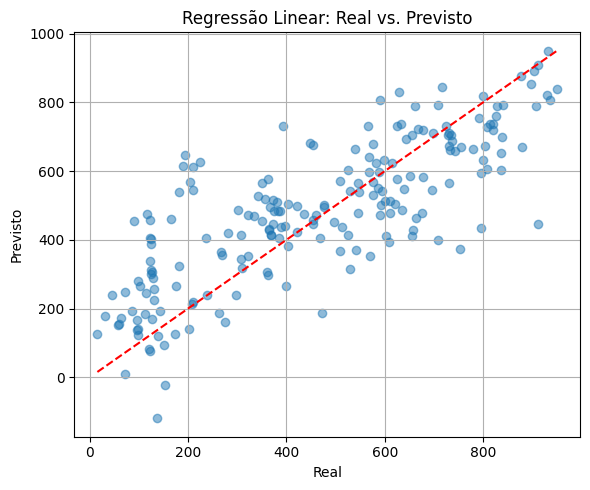

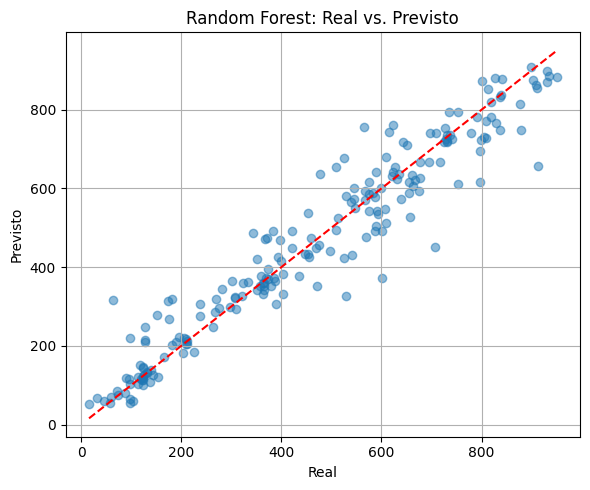

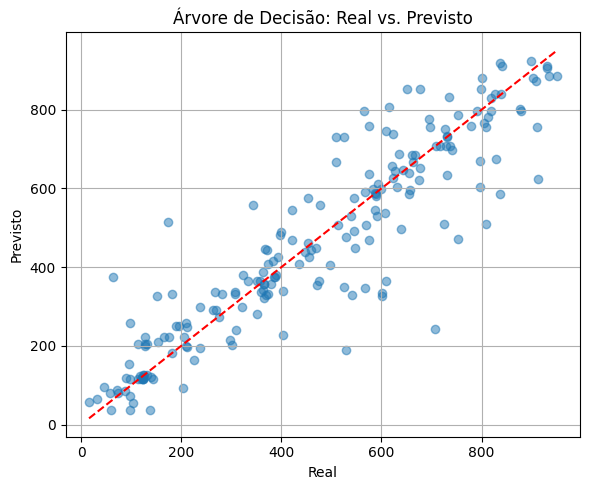

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# Calculando métricas para Regressão Linear
mae_reg_linear = mean_absolute_error(y_test_tf2, y_pred_reg_linear_tf2)
mse_reg_linear = mean_squared_error(y_test_tf2, y_pred_reg_linear_tf2)
r2_reg_linear = r2_score(y_test_tf2, y_pred_reg_linear_tf2)

# Calculando métricas para Random Forest Regressor
mae_rf = mean_absolute_error(y_test_tf2, y_pred_rf_tf2)
mse_rf = mean_squared_error(y_test_tf2, y_pred_rf_tf2)
r2_rf = r2_score(y_test_tf2, y_pred_rf_tf2)

# Calculando métricas para Decision Tree Regressor
mae_dt = mean_absolute_error(y_test_tf2, y_pred_dt_tf2)
mse_dt = mean_squared_error(y_test_tf2, y_pred_dt_tf2)
r2_dt = r2_score(y_test_tf2, y_pred_dt_tf2)

# Criando um DataFrame para exibir as métricas
metrics_df = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest', 'Árvore de Decisão'],
    'MAE': [mae_reg_linear, mae_rf, mae_dt],
    'MSE': [mse_reg_linear, mse_rf, mse_dt],
    'R²': [r2_reg_linear, r2_rf, r2_dt]
})

print("Comparação de Métricas de Regressão:\n")
print(metrics_df.set_index('Modelo'))

# Gráfico para Regressão Linear
plt.figure(figsize=(6, 5))
plt.scatter(y_test_tf2, y_pred_reg_linear_tf2, alpha=0.5)
plt.plot([y_test_tf2.min(), y_test_tf2.max()], [y_test_tf2.min(), y_test_tf2.max()], 'r--')
plt.title('Regressão Linear: Real vs. Previsto')
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico para Random Forest Regressor
plt.figure(figsize=(6, 5))
plt.scatter(y_test_tf2, y_pred_rf_tf2, alpha=0.5)
plt.plot([y_test_tf2.min(), y_test_tf2.max()], [y_test_tf2.min(), y_test_tf2.max()], 'r--')
plt.title('Random Forest: Real vs. Previsto')
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico para Decision Tree Regressor
plt.figure(figsize=(6, 5))
plt.scatter(y_test_tf2, y_pred_dt_tf2, alpha=0.5)
plt.plot([y_test_tf2.min(), y_test_tf2.max()], [y_test_tf2.min(), y_test_tf2.max()], 'r--')
plt.title('Árvore de Decisão: Real vs. Previsto')
plt.xlabel('Real')
plt.ylabel('Previsto')
plt.grid(True)
plt.tight_layout()
plt.show()

## RELATÓRIO

**Interpretação dos Erros (MAE, MSE, R²):**

Ao comparar as métricas dos três modelos, observamos:

*   **Random Forest Regressor** apresenta os melhores resultados, com o menor MAE (48.75 W/m²), menor MSE (4865.90 (W/m²)²) e o maior R² (0.9288).
    *   **MAE:** Em média, as previsões do Random Forest se desviam dos valores reais em aproximadamente 48.75 W/m². Considerando a faixa de radiação solar (que pode ir de 0 a mais de 1000 W/m²), este é um erro relativamente baixo, indicando boa precisão.
    *   **MSE:** O MSE penaliza erros maiores mais severamente. O valor baixo para o Random Forest reforça sua boa performance, indicando que não há muitos erros extremos.
    *   **R²:** Um R² de 0.9288 significa que o modelo Random Forest consegue explicar cerca de 92.88% da variância na radiação solar, o que é um resultado excelente para este tipo de previsão.

*   **Árvore de Decisão** (MAE: 64.12 W/m², MSE: 8559.64 (W/m²)², R²: 0.8748) performa de forma razoável, mas é superado pelo Random Forest. Isso é esperado, pois Random Forest é um ensemble de árvores de decisão, que geralmente suaviza o overfitting e melhora a generalização.

*   **Regressão Linear** (MAE: 125.92 W/m², MSE: 26610.24 (W/m²)², R²: 0.6108) é o modelo com pior desempenho. Seu R² de 0.6108 indica que ele explica apenas 61.08% da variância, e seus erros (MAE e MSE) são significativamente maiores. Isso sugere que a relação entre as variáveis de entrada e a radiação solar não é puramente linear, ou que há complexidades que a regressão linear não consegue capturar.

**Peso da Coluna 'hora':**

A coluna `hora` é um fator importante para a radiação solar. A radiação solar é um fenômeno diurno, variando ao longo do dia, com picos ao meio-dia e valores próximos de zero nas primeiras e últimas horas de sol. Sem a `hora` como entrada, seria impossível capturar essa variação.

**Estimativa da radiação solar vs. energia produzida por um sistema fotovoltaico:**

A estimativa da radiação solar em W/m² **não prevê automaticamente a energia produzida** por um sistema fotovoltaico, e há várias razões para isso:

1.  **Orientação e Inclinação:** A radiação W/m² fornecida pela API é geralmente a radiação solar global horizontal. No entanto, um painel fotovoltaico é instalado com uma orientação e inclinação específicas para maximizar a captação de energia. A radiação que atinge a superfície do painel é diferente da GHI e depende desses fatores.

2.  **Temperatura do Painel:** A eficiência dos painéis fotovoltaicos diminui com o aumento da temperatura. Mesmo em um dia com alta radiação, um painel muito quente produzirá menos energia do que um mais frio.

3.  **Perdas no Sistema:** Existem diversas perdas em um sistema fotovoltaico que não são capturadas pela radiação solar, como por exemplo: sujeira, fiação, degradação natural etc:
  
4.  **Características do Painel:** Diferentes tecnologias de painéis fotovoltaicos têm diferentes eficiências por exemplo: silício monocristalino vs. policristalino vs. filme fino.


Para prever a energia produzida por um sistema fotovoltaico, seria necessário um modelo mais complexo que leve em consideração todos esses fatores adicionais, além da radiação solar estimada.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)